Copyright © 2024, Andrea Mastropietro. All rights reserved.

This code is licensed under the MIT License.

See the LICENSE file in the project root for more information.

## Plot Hausdorff distances with atom removal and injection
Plotting examplary cases

In [1]:
from matplotlib import pyplot as plt
import pickle

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

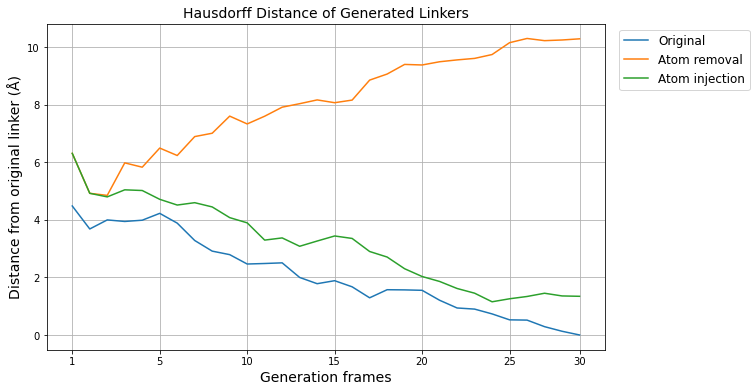

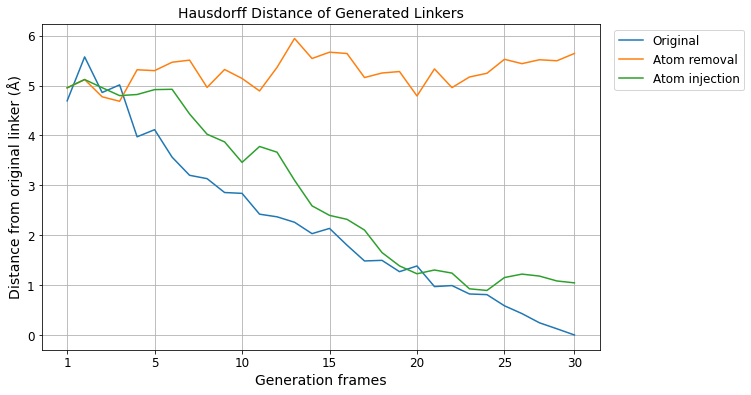

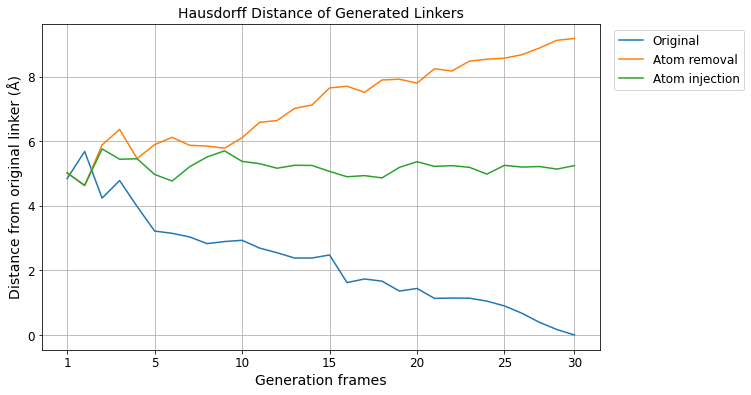

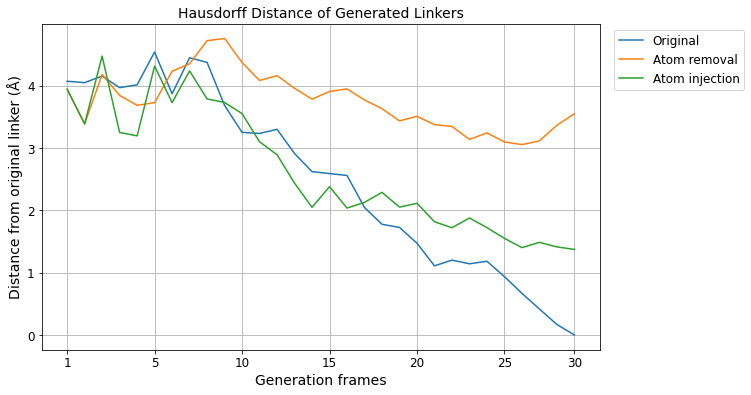

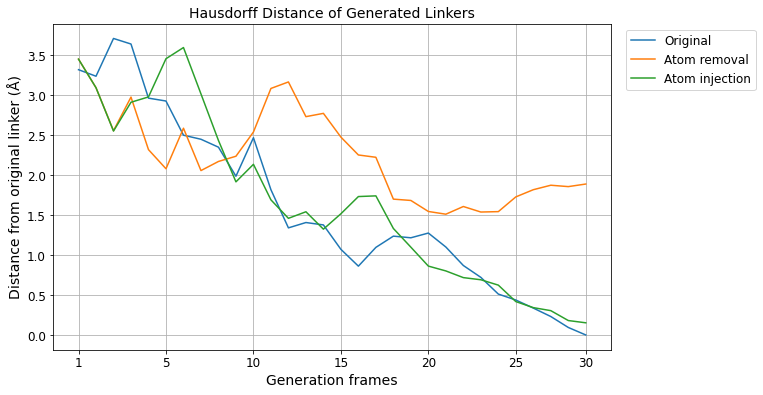

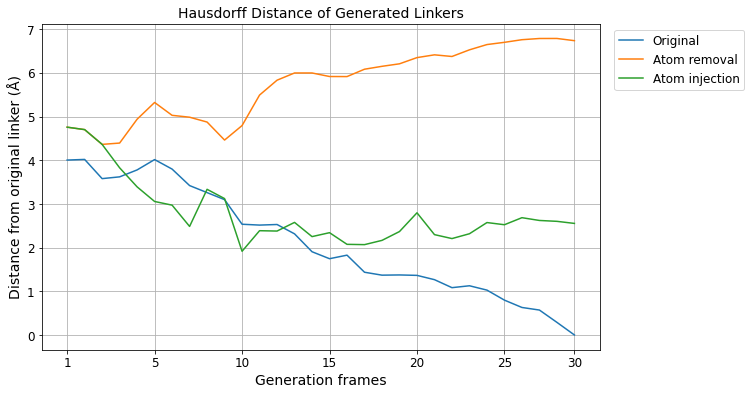

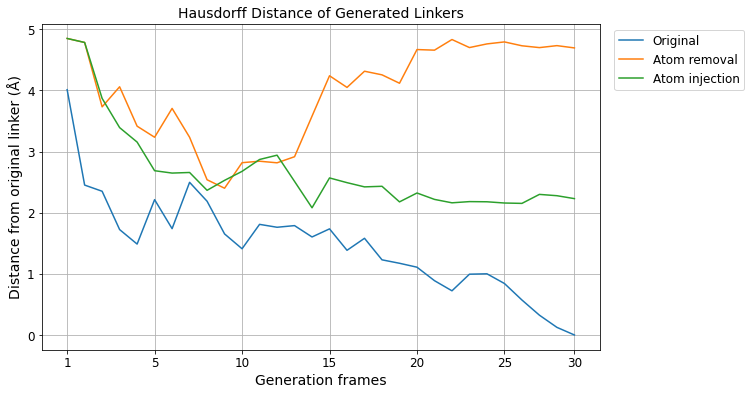

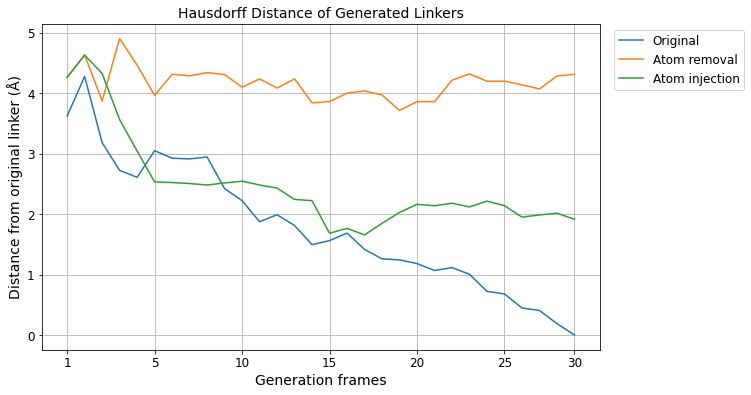

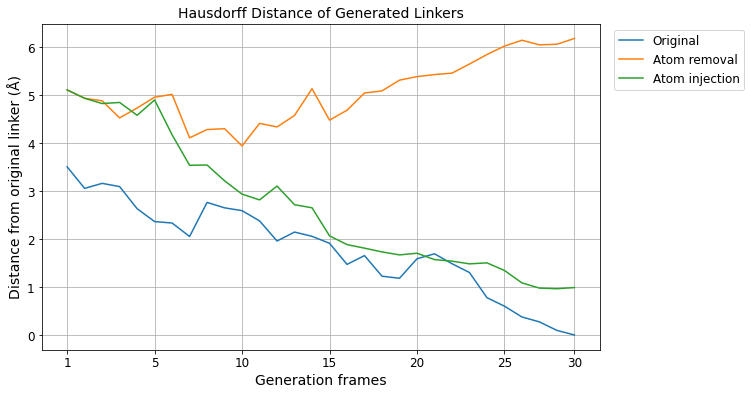

In [2]:
distance_folder = "../results/neighbor_atom_analysis/zinc_final_test/seed_42/"

indices_to_plot = [3, 4, 7, 13, 14, 22, 27, 28, 29]


for idx in indices_to_plot:

    plt.figure(figsize=(10, 6))
    with open(f"{distance_folder}{idx}/hausdorff_distances_original.pkl", "rb") as file:
        distances = pickle.load(file)
        plt.plot(range(1, len(distances)+1), distances, label=f"Data Index {idx}")

    with open(f"{distance_folder}{idx}/hausdorff_distances_perturbation_removal.pkl", "rb") as file:
        distances = pickle.load(file)
        plt.plot(range(1, len(distances)+1), distances, label=f"Data Index {idx} Perturbation 0")
    with open(f"{distance_folder}{idx}/hausdorff_distances_perturbation_injection.pkl", "rb") as file:
        distances = pickle.load(file)
        plt.plot(range(1, len(distances)+1), distances, label=f"Data Index {idx} Perturbation 0 Injection")
    
    
    plt.rc('axes', labelsize=14)  
    plt.rc('xtick', labelsize=12) 
    plt.rc('ytick', labelsize=12) 
    plt.title('Hausdorff Distance of Generated Linkers', fontsize=14)
    plt.xlabel('Generation frames', fontsize=14)
    plt.ylabel('Distance from original linker (Å)', fontsize=14)
    custom_legend_names = ["Original", "Atom removal", "Atom injection"]
    plt.legend(custom_legend_names, loc='upper right', fontsize=12, bbox_to_anchor=(1.27, 1))
    # plt.xticks(ticks=range(1, 31, 5))
    plt.xticks(ticks=list(range(1, len(distances), 5)) + [len(distances)], labels=[1] + list(range(5, len(distances), 5)) + [len(distances)])
    plt.grid(True)
    plt.savefig(f"../results/neighbor_atom_analysis/hausdorff_distance_trend_{idx}.pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"../results/neighbor_atom_analysis/hausdorff_distance_trend_{idx}.png", dpi=300, bbox_inches='tight')
    plt.show()
